**Install Libraries and Load Dataset**

In [1]:
!pip install -q plotly kaleido

#Import all the libraries we'll need throughout the project
import pandas as pd               #For working with tabular data (like Excel in Python)
import numpy as np                #For math operations on arrays
import matplotlib.pyplot as plt   #For plotting graphs
import seaborn as sns             #For prettier statistical plots
import plotly.express as px       #For interactive charts
import warnings
warnings.filterwarnings('ignore') #Suppress minor warnings so output stays clean

#Scikit-learn: the main ML library we'll use
from sklearn.preprocessing import StandardScaler       #To scale features
from sklearn.cluster import KMeans                     #The clustering algorithm
from sklearn.decomposition import PCA                  #To reduce dimensions for visualisation
from sklearn.metrics import silhouette_score           #To evaluate cluster quality

#Set visual style for all matplotlib plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)  #Default figure size

print("All libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 3.9 MB/s eta 0:00:00
All libraries imported successfully!


**Upload the dataset**

In [2]:
#Load the CSV into a DataFrame
df = pd.read_csv('dataset.csv')

#Basic inspection
print("Shape of dataset (rows, columns):", df.shape)
print("\n--- First 5 rows ---")
df.head()

Shape of dataset (rows, columns): (114000, 21)

--- First 5 rows ---


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


**Check column names and data types**

In [3]:
print("--- Column names and data types ---")
print(df.info())

--- Column names and data types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-nul

In [4]:
df.describe().round(2)

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00
mean,56999.50,33.24,228029.15,0.57,0.64,5.31,-8.26,0.64,0.08,0.31,0.16,0.21,0.47,122.15,3.90
std,32909.11,22.31,107297.71,0.17,0.25,3.56,5.03,0.48,0.11,0.33,0.31,0.19,0.26,29.98,0.43
min,0.00,0.00,0.00,0.00,0.00,0.00,-49.53,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,28499.75,17.00,174066.00,0.46,0.47,2.00,-10.01,0.00,0.04,0.02,0.00,0.10,0.26,99.22,4.00
50%,56999.50,35.00,212906.00,0.58,0.68,5.00,-7.00,1.00,0.05,0.17,0.00,0.13,0.46,122.02,4.00
75%,85499.25,50.00,261506.00,0.70,0.85,8.00,-5.00,1.00,0.08,0.60,0.05,0.27,0.68,140.07,4.00
max,113999.00,100.00,5237295.00,0.98,1.00,11.00,4.53,1.00,0.96,1.00,1.00,1.00,1.00,243.37,5.00


**Check for missing values and duplicates**


In [5]:
print("--- Missing values per column ---")
print(df.isnull().sum())

print(f"\nDuplicate rows: {df.duplicated().sum()}")

--- Missing values per column ---
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Duplicate rows: 0


**Clean the dataset**

In [6]:
df = df.dropna(subset=['track_name', 'artists', 'album_name'])

df = df.drop(columns=['Unnamed: 0'])

df = df[df['duration_ms'] <= 600000]

print(f"Rows before cleaning: 114000")
print(f"Rows after cleaning:  {len(df)}")
print(f"Rows removed: {114000 - len(df)}")
print(f"\nColumns remaining: {df.shape[1]}")
print(df.columns.tolist())

Rows before cleaning: 114000
Rows after cleaning:  113396
Rows removed: 604

Columns remaining: 20
['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


**Distribution of all 9 audio features**

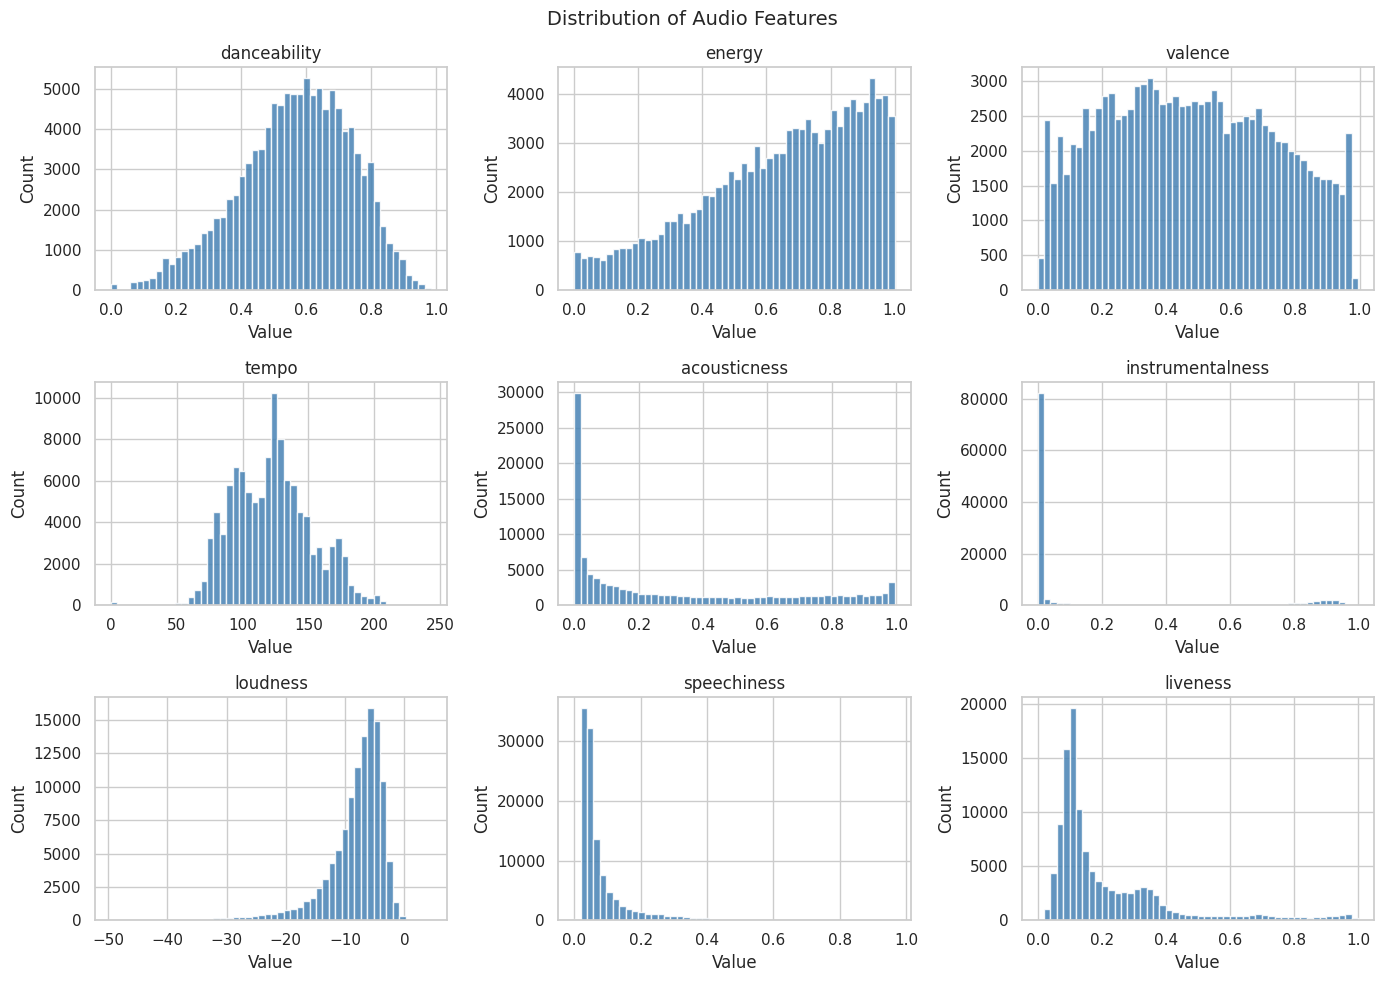

In [7]:
audio_features = [
    'danceability', 'energy', 'valence', 'tempo',
    'acousticness', 'instrumentalness', 'loudness',
    'speechiness', 'liveness'
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(audio_features):
    axes[i].hist(df[feature], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(feature, fontsize=12)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of Audio Features', fontsize=14)
plt.tight_layout()
plt.show()

**Correlation heatmap**

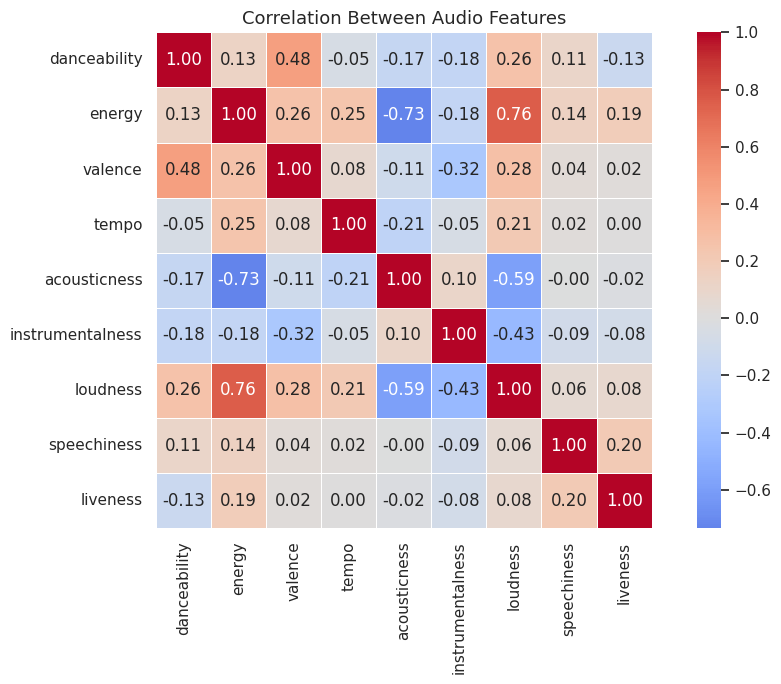

In [8]:
#Shows how related each feature is to every other feature
#Also helps to spot redundant features before clustering
plt.figure(figsize=(10, 7))
correlation_matrix = df[audio_features].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,       #Show correlation number inside each cell
    fmt='.2f',        #Round to 2 decimal places
    cmap='coolwarm',  #Red = strong positive, Blue = strong negative
    center=0,         #White = 0 (no correlation)
    linewidths=0.5,
    square=True
)

plt.title('Correlation Between Audio Features', fontsize=13)
plt.tight_layout()
plt.show()

**Top Genres by song count**

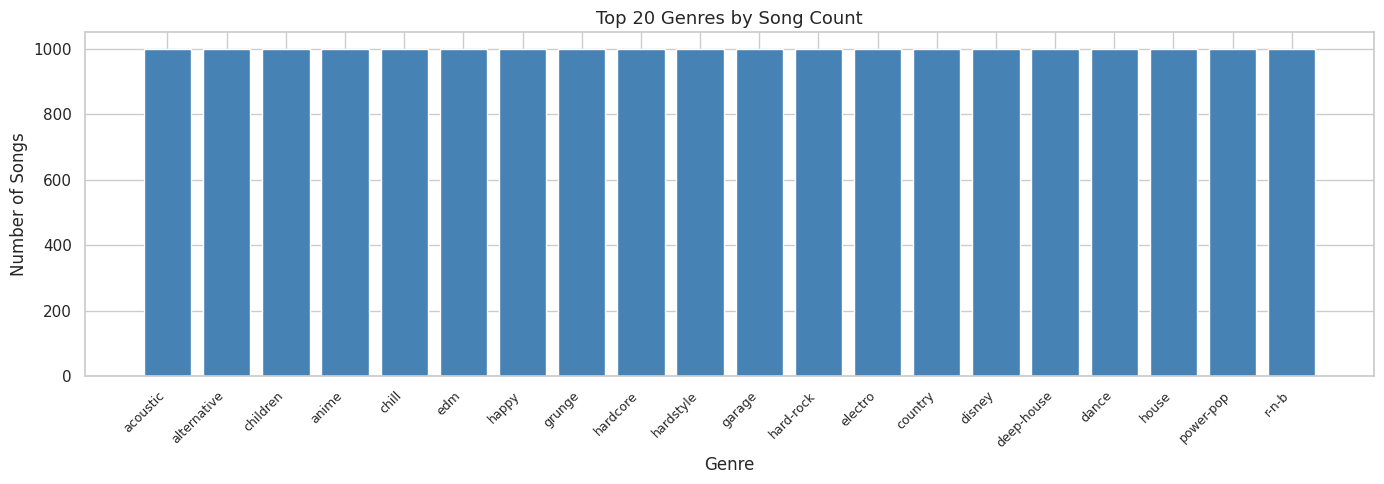

Total unique genres: 114

Songs per genre (min/max/mean):
  Min:  942
  Max:  1000
  Mean: 995


In [9]:
plt.figure(figsize=(14, 5))

genre_counts = df['track_genre'].value_counts()

plt.bar(genre_counts.index[:20], genre_counts.values[:20],
        color='steelblue', edgecolor='white')

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel('Number of Songs')
plt.xlabel('Genre')
plt.title('Top 20 Genres by Song Count', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Total unique genres: {df['track_genre'].nunique()}")
print(f"\nSongs per genre (min/max/mean):")
print(f"  Min:  {genre_counts.min()}")
print(f"  Max:  {genre_counts.max()}")
print(f"  Mean: {genre_counts.mean():.0f}")

**Feature Scaling with StandardScaler**

In [10]:
df_features = df[audio_features].copy()

print(f"Shape before scaling: {df_features.shape}")
print(f"Sample of raw values (first row):\n{df_features.iloc[0]}")

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_features)

print(f"\nShape after scaling: {df_scaled.shape}")
print(f"\nMean of each scaled feature (should be ~0):")
print(df_scaled.mean(axis=0).round(3))
print(f"\nStd of each scaled feature (should be ~1):")
print(df_scaled.std(axis=0).round(3))

Shape before scaling: (113396, 9)
Sample of raw values (first row):
danceability         0.676000
energy               0.461000
valence              0.715000
tempo               87.917000
acousticness         0.032200
instrumentalness     0.000001
loudness            -6.746000
speechiness          0.143000
liveness             0.358000
Name: 0, dtype: float64

Shape after scaling: (113396, 9)

Mean of each scaled feature (should be ~0):
[-0. -0. -0. -0. -0.  0.  0. -0. -0.]

Std of each scaled feature (should be ~1):
[1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Finding Optimal K
We test K=2 to K=10 using two methods:
- Elbow Method: plots inertia vs K, we look for the bend
- Silhouette Score: measures cluster separation quality (-1 to +1)

**Elbow method + Silhouette score to find optimal K**

In [11]:
np.random.seed(42)
sample_idx = np.random.choice(len(df_scaled), size=30000, replace=False)
df_sample = df_scaled[sample_idx]

inertia_values = []
silhouette_values = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',  #Smarter initialisation than random
        n_init=10,
        random_state=42,
        max_iter=300
    )
    kmeans.fit(df_sample)
    inertia_values.append(kmeans.inertia_)

    sil = silhouette_score(df_sample, kmeans.labels_,
                           sample_size=5000, random_state=42)
    silhouette_values.append(sil)

    print(f"K={k:2d} | Inertia: {kmeans.inertia_:,.0f} | Silhouette: {sil:.4f}")

print("\nDone!")

K= 2 | Inertia: 211,455 | Silhouette: 0.2605
K= 3 | Inertia: 187,635 | Silhouette: 0.1676
K= 4 | Inertia: 169,868 | Silhouette: 0.1752
K= 5 | Inertia: 153,051 | Silhouette: 0.1798
K= 6 | Inertia: 140,003 | Silhouette: 0.1877
K= 7 | Inertia: 127,416 | Silhouette: 0.1986
K= 8 | Inertia: 120,249 | Silhouette: 0.2007
K= 9 | Inertia: 113,584 | Silhouette: 0.1779
K=10 | Inertia: 109,028 | Silhouette: 0.1688

Done!


**Plot elbow curve and silhouette scores**

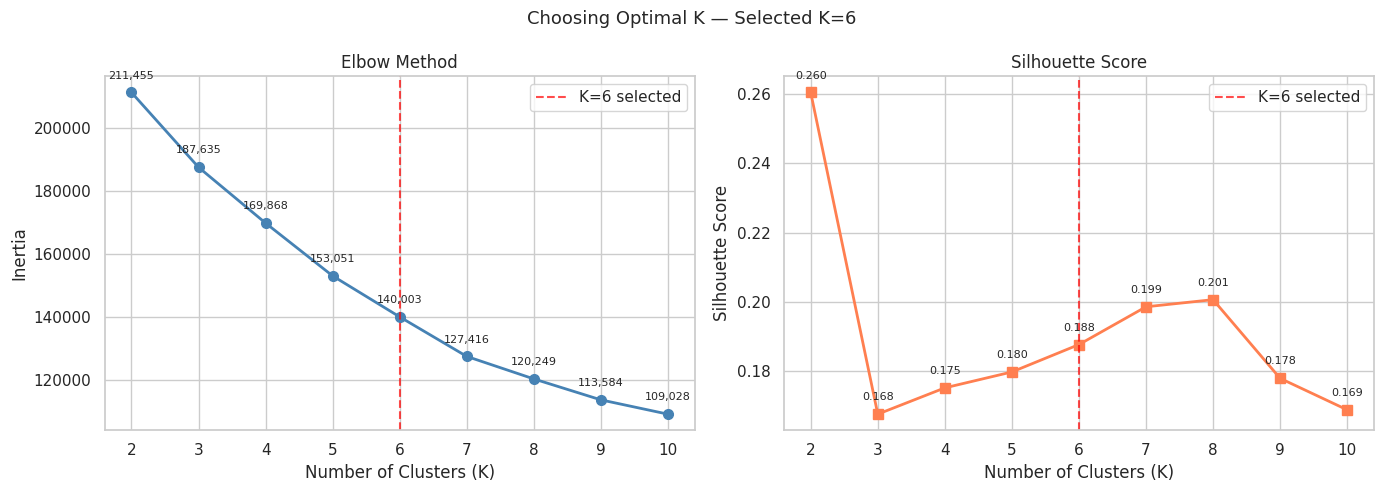

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#--- Elbow plot ---
axes[0].plot(list(K_range), inertia_values,
             marker='o', color='steelblue', linewidth=2, markersize=7)
axes[0].axvline(x=6, color='red', linestyle='--', alpha=0.7, label='K=6 selected')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(K_range))
axes[0].legend()

#Annotate inertia drop at each point
for k, val in zip(K_range, inertia_values):
    axes[0].annotate(f'{val:,.0f}', (k, val),
                     textcoords="offset points",
                     xytext=(0, 10), ha='center', fontsize=8)

#--- Silhouette plot ---
axes[1].plot(list(K_range), silhouette_values,
             marker='s', color='coral', linewidth=2, markersize=7)
axes[1].axvline(x=6, color='red', linestyle='--', alpha=0.7, label='K=6 selected')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].set_xticks(list(K_range))
axes[1].legend()

for k, val in zip(K_range, silhouette_values):
    axes[1].annotate(f'{val:.3f}', (k, val),
                     textcoords="offset points",
                     xytext=(0, 10), ha='center', fontsize=8)

plt.suptitle('Choosing Optimal K — Selected K=6', fontsize=13)
plt.tight_layout()
plt.show()

**Train final KMeans Model**

In [13]:
OPTIMAL_K = 6

print(f"Training final KMeans with K={OPTIMAL_K} on {len(df_scaled)} songs...")

kmeans_final = KMeans(
    n_clusters=OPTIMAL_K,
    init='k-means++',
    n_init=10,
    random_state=42,
    max_iter=300
)

kmeans_final.fit(df_scaled)

#Add cluster labels back to the features dataframe
df_features['cluster'] = kmeans_final.labels_

#Also add cluster to the main df for genre analysis later
df['cluster'] = kmeans_final.labels_

print("Training complete!")
print(f"\nSongs per cluster:")
cluster_counts = df_features['cluster'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    pct = count / len(df_features) * 100
    print(f"  Cluster {cluster_id}: {count:,} songs ({pct:.1f}%)")

Training final KMeans with K=6 on 113396 songs...
Training complete!

Songs per cluster:
  Cluster 0: 23,147 songs (20.4%)
  Cluster 1: 11,671 songs (10.3%)
  Cluster 2: 7,272 songs (6.4%)
  Cluster 3: 7,851 songs (6.9%)
  Cluster 4: 36,533 songs (32.2%)
  Cluster 5: 26,922 songs (23.7%)


**PCA**

Applying PCA...
Variance explained by PC1: 31.9%
Variance explained by PC2: 15.9%
Total variance captured:   47.7%


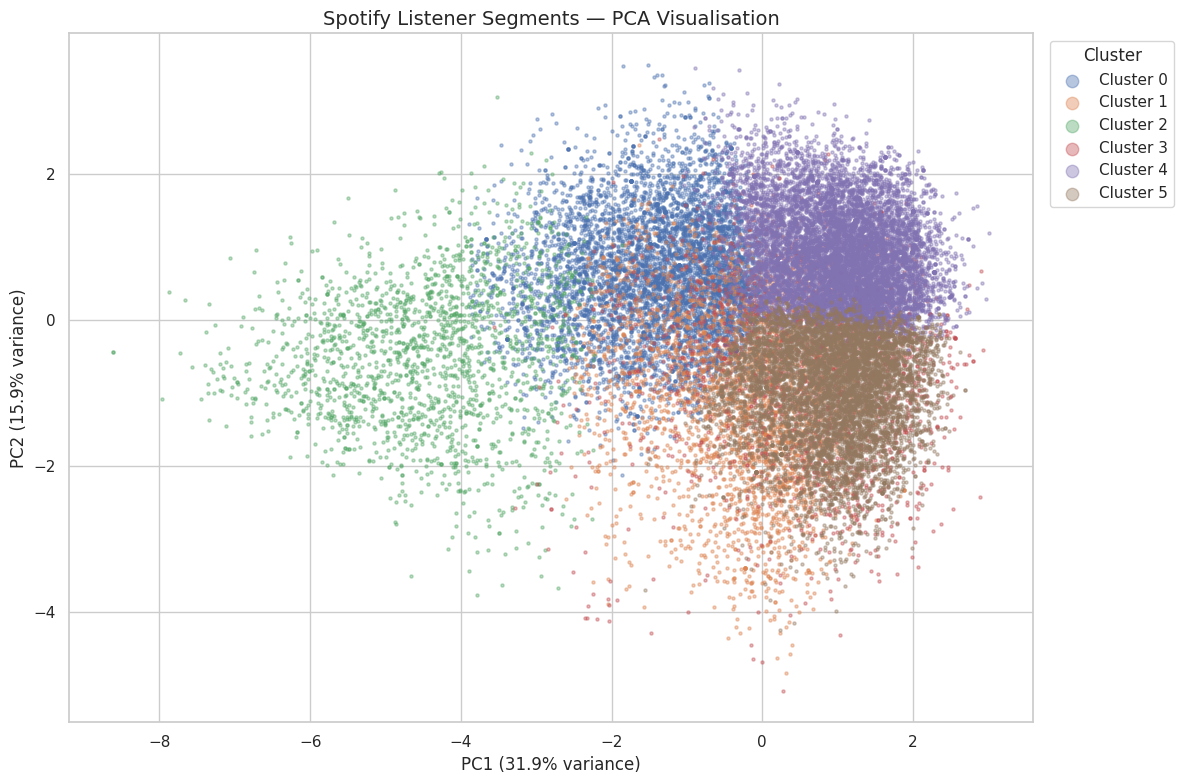

In [14]:
print("Applying PCA...")

pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(df_scaled)

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total variance captured:   {sum(pca.explained_variance_ratio_)*100:.1f}%")

#Build a clean dataframe for plotting
pca_df = pd.DataFrame({
    'PC1'    : pca_coords[:, 0],
    'PC2'    : pca_coords[:, 1],
    'cluster': df_features['cluster'].values
})

#Plot on a sample of 30K — plotting 113K points is slow and cluttered
sample_mask = np.random.choice(len(pca_df), size=30000, replace=False)
pca_sample  = pca_df.iloc[sample_mask]

colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']

plt.figure(figsize=(12, 8))
for cluster_id in range(OPTIMAL_K):
    mask = pca_sample['cluster'] == cluster_id
    plt.scatter(
        pca_sample.loc[mask, 'PC1'],
        pca_sample.loc[mask, 'PC2'],
        s=5,
        alpha=0.4,
        color=colors[cluster_id],
        label=f'Cluster {cluster_id}'
    )

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Spotify Listener Segments — PCA Visualisation', fontsize=14)
plt.legend(markerscale=4, title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Cluster Profiling**

In [15]:
cluster_profile = df_features.groupby('cluster')[audio_features].mean().round(3)

print("=== Mean feature values per cluster ===\n")
print(cluster_profile.to_string())

=== Mean feature values per cluster ===

         danceability  energy  valence    tempo  acousticness  instrumentalness  loudness  speechiness  liveness
cluster                                                                                                         
0               0.531   0.378    0.392  113.157         0.676             0.028   -10.607        0.053     0.159
1               0.586   0.742    0.341  126.875         0.111             0.789    -8.372        0.071     0.174
2               0.349   0.169    0.188  103.179         0.866             0.786   -21.224        0.052     0.161
3               0.532   0.744    0.504  120.187         0.354             0.052    -7.570        0.195     0.751
4               0.705   0.721    0.693  117.638         0.208             0.018    -6.398        0.093     0.165
5               0.473   0.816    0.377  139.758         0.074             0.032    -5.321        0.082     0.199


**Validate cluster names using genre data**

In [16]:
print("=== Top 8 genres per cluster ===\n")
for cluster_id in range(OPTIMAL_K):
    top_genres = (df[df['cluster'] == cluster_id]['track_genre']
                  .value_counts()
                  .head(8))
    print(f"Cluster {cluster_id}:")
    print(top_genres.to_string())
    print()

=== Top 8 genres per cluster ===

Cluster 0:
track_genre
tango                782
romance              779
honky-tonk           773
jazz                 743
cantopop             699
songwriter           648
singer-songwriter    648
mandopop             633

Cluster 1:
track_genre
minimal-techno    859
detroit-techno    722
techno            626
study             609
grindcore         542
chicago-house     500
idm               496
trance            494

Cluster 2:
track_genre
sleep        764
new-age      743
classical    727
ambient      655
piano        559
guitar       453
disney       432
iranian      403

Cluster 3:
track_genre
comedy       809
pagode       478
samba        412
sertanejo    401
mpb          262
brazil       197
gospel       190
forro        171

Cluster 4:
track_genre
latino       875
reggaeton    873
reggae       851
dancehall    836
latin        806
kids         787
salsa        786
hip-hop      708

Cluster 5:
track_genre
metalcore      860
heavy-metal    736
g

**Assign Final Names and Visualise distribution**

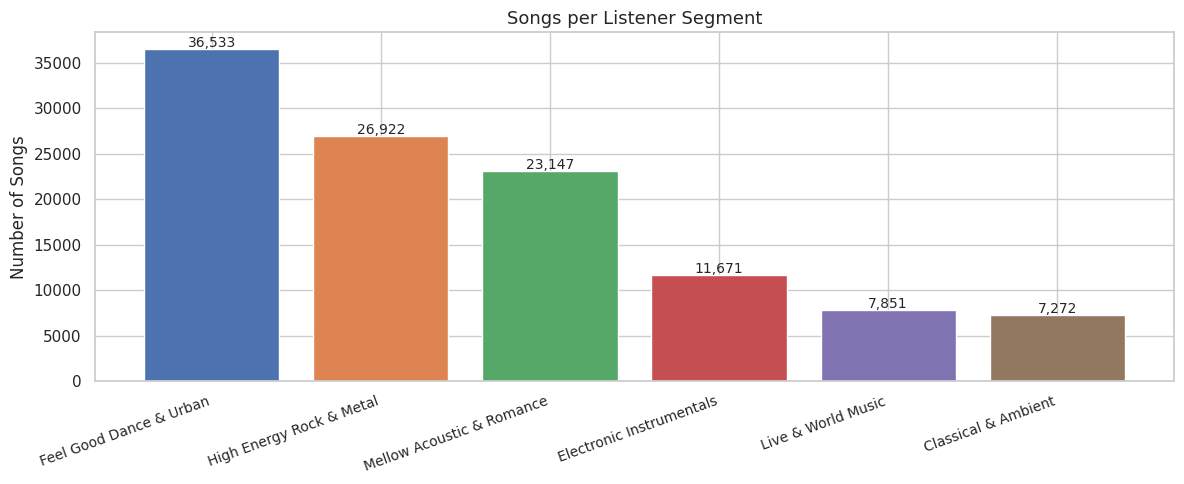

In [17]:
cluster_labels = {
    0: 'Mellow Acoustic & Romance',
    1: 'Electronic Instrumentals',
    2: 'Classical & Ambient',
    3: 'Live & World Music',
    4: 'Feel Good Dance & Urban',
    5: 'High Energy Rock & Metal'
}

df['segment_name'] = df['cluster'].map(cluster_labels)
df_features['segment_name'] = df_features['cluster'].map(cluster_labels)

# Plot segment distribution
plt.figure(figsize=(12, 5))
segment_counts = df['segment_name'].value_counts()

bars = plt.bar(segment_counts.index, segment_counts.values,
               color=colors, edgecolor='white')

for bar, val in zip(bars, segment_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 200,
             f'{val:,}', ha='center', fontsize=10)

plt.xticks(rotation=20, ha='right', fontsize=10)
plt.ylabel('Number of Songs')
plt.title('Songs per Listener Segment', fontsize=13)
plt.tight_layout()
plt.show()

**Radar Charts**

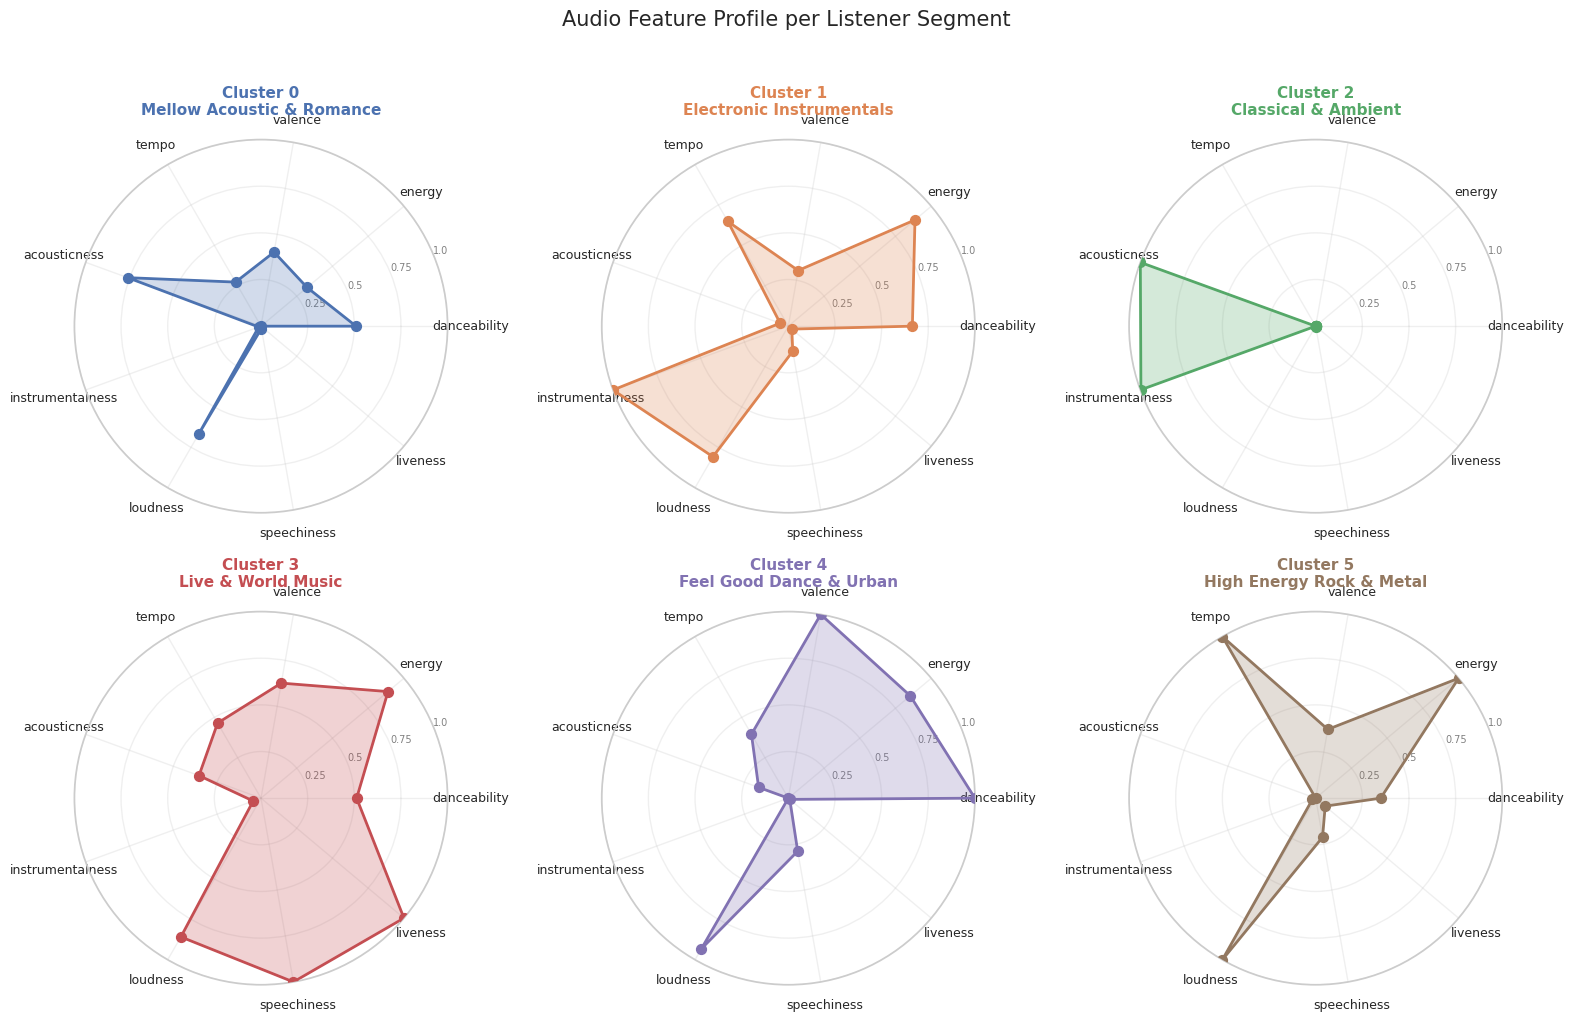

In [18]:
from matplotlib.patches import FancyArrowPatch
from sklearn.preprocessing import MinMaxScaler

#Normalise cluster profiles to 0-1 so all features fit on same radar scale
norm_scaler = MinMaxScaler()
cluster_profile = df_features.groupby('cluster')[audio_features].mean()
profile_normalised = pd.DataFrame(
    norm_scaler.fit_transform(cluster_profile),
    columns=audio_features,
    index=cluster_profile.index
)

#Radar chart setup
N = len(audio_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  #Close the polygon

fig, axes = plt.subplots(2, 3, figsize=(16, 10),
                         subplot_kw=dict(polar=True))
axes = axes.flatten()

radar_colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']

for i, cluster_id in enumerate(range(OPTIMAL_K)):
    values = profile_normalised.loc[cluster_id].tolist()
    values += values[:1]  #Close the polygon

    ax = axes[i]

    #Fill area
    ax.fill(angles, values, color=radar_colors[i], alpha=0.25)
    #Draw outline
    ax.plot(angles, values, color=radar_colors[i], linewidth=2)
    #Draw dots at each feature point
    ax.scatter(angles[:-1], values[:-1],
               color=radar_colors[i], s=50, zorder=5)

    #Feature labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(audio_features, size=9)

    #Radial grid labels
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25','0.5','0.75','1.0'], size=7, color='grey')
    ax.set_ylim(0, 1)

    #Title with cluster name
    name = cluster_labels[cluster_id]
    ax.set_title(f'Cluster {cluster_id}\n{name}',
                 size=11, fontweight='bold',
                 pad=18, color=radar_colors[i])
    ax.grid(True, alpha=0.3)

plt.suptitle('Audio Feature Profile per Listener Segment',
             fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## Business Recommendations
Based on the 6 segments identified, here are actionable
recommendations for Spotify's product and marketing teams.

**Business Insights Summary**

In [20]:
print("=" * 62)
print("   SPOTIFY LISTENER SEGMENTATION — BUSINESS SUMMARY")
print("=" * 62)

summary_data = {
    0: {
        'name'   : 'Mellow Acoustic & Romance',
        'size'   : '23,147 songs (20.4%)',
        'traits' : 'High acousticness, low energy, low valence',
        'genres' : 'Tango, Romance, Jazz, Singer-songwriter',
        'insight': 'Target with Spotify Mixes for late night/focus listening'
    },
    1: {
        'name'   : 'Electronic Instrumentals',
        'size'   : '11,671 songs (10.3%)',
        'traits' : 'High energy, very high instrumentalness, low acousticness',
        'genres' : 'Techno, Minimal-techno, Study, IDM, Trance',
        'insight': 'Target with Focus/Study playlists and premium offline features'
    },
    2: {
        'name'   : 'Classical & Ambient',
        'size'   : '7,272 songs (6.4%)',
        'traits' : 'Highest acousticness + instrumentalness, very low energy',
        'genres' : 'Sleep, New-age, Classical, Ambient, Piano',
        'insight': 'Target with Spotify Sleep and HiFi lossless audio upsell'
    },
    3: {
        'name'   : 'Live & World Music',
        'size'   : '7,851 songs (6.9%)',
        'traits' : 'Highest liveness by far, broad energy and valence',
        'genres' : 'Samba, Pagode, Sertanejo, MPB, Brazil, Gospel',
        'insight': 'Target with concert/event ticket promotions via Spotify'
    },
    4: {
        'name'   : 'Feel Good Dance & Urban',
        'size'   : '36,533 songs (32.2%)',
        'traits' : 'Highest danceability + valence, high energy, loud',
        'genres' : 'Latino, Reggaeton, Reggae, Dancehall, Hip-hop',
        'insight': 'Largest segment — prime target for ad-supported tier monetisation'
    },
    5: {
        'name'   : 'High Energy Rock & Metal',
        'size'   : '26,922 songs (23.7%)',
        'traits' : 'Highest energy + tempo, very loud, low acousticness',
        'genres' : 'Metalcore, Heavy-metal, Grunge, Dubstep, Hardstyle',
        'insight': 'Target with gym/workout playlist features and merch partnerships'
    }
}

for cluster_id, info in summary_data.items():
    print(f"\nSegment {cluster_id}: {info['name']}")
    print(f"  Size    : {info['size']}")
    print(f"  Traits  : {info['traits']}")
    print(f"  Genres  : {info['genres']}")
    print(f"  Action  : {info['insight']}")

print("\n" + "=" * 62)

#Save outputs
df[audio_features + ['track_name','artists','track_genre',
                      'cluster','segment_name']].to_csv('spotify_segments.csv',
                                                         index=False)

cluster_profile['segment_name'] = pd.Series(cluster_labels)
cluster_profile.to_csv('cluster_profiles.csv')

print("\nFiles saved:")
print("  spotify_segments.csv  — full dataset with cluster labels")
print("  cluster_profiles.csv  — mean feature values per cluster")

   SPOTIFY LISTENER SEGMENTATION — BUSINESS SUMMARY

Segment 0: Mellow Acoustic & Romance
  Size    : 23,147 songs (20.4%)
  Traits  : High acousticness, low energy, low valence
  Genres  : Tango, Romance, Jazz, Singer-songwriter
  Action  : Target with Spotify Mixes for late night/focus listening

Segment 1: Electronic Instrumentals
  Size    : 11,671 songs (10.3%)
  Traits  : High energy, very high instrumentalness, low acousticness
  Genres  : Techno, Minimal-techno, Study, IDM, Trance
  Action  : Target with Focus/Study playlists and premium offline features

Segment 2: Classical & Ambient
  Size    : 7,272 songs (6.4%)
  Traits  : Highest acousticness + instrumentalness, very low energy
  Genres  : Sleep, New-age, Classical, Ambient, Piano
  Action  : Target with Spotify Sleep and HiFi lossless audio upsell

Segment 3: Live & World Music
  Size    : 7,851 songs (6.9%)
  Traits  : Highest liveness by far, broad energy and valence
  Genres  : Samba, Pagode, Sertanejo, MPB, Brazil, G